# Atelier : Application des ALE (Accumulated Local Effects)

**Version FIXÉE - Implémentation manuelle ALE**

**Objectifs:**
- Comprendre comment appliquer les ALE
- Savoir interpréter les graphiques
- Apprendre à combiner plusieurs ALE
- Étudier l'effet du choix de la taille des intervalles

---

## 1. Importation des bibliothèques

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

print("✓ Bibliothèques importées avec succès")

✓ Bibliothèques importées avec succès


## 2. Fonction ALE manuelle

Implémentation simple d'ALE pour éviter les bugs des bibliothèques externes

In [22]:
def compute_ale(model, X, feature, bins=20):
    """
    Calcule l'ALE (Accumulated Local Effects) pour une feature.
    
    Parameters:
    -----------
    model : sklearn model
        Modèle entraîné
    X : pd.DataFrame
        Données d'entraînement
    feature : str
        Nom de la feature
    bins : int
        Nombre d'intervalles
    
    Returns:
    --------
    bin_centers, ale_values
    """
    X_copy = X.copy()
    feature_values = X_copy[feature].values
    
    # Créer les quantiles pour les bins
    quantiles = np.linspace(0, 1, bins + 1)
    bin_edges = np.percentile(feature_values, quantiles * 100)
    bin_edges = np.unique(bin_edges)  # Remove duplicates
    
    if len(bin_edges) < 2:
        print(f"Warning: Not enough unique values for {feature}")
        return None, None
    
    ale_values = []
    bin_centers = []
    
    for i in range(len(bin_edges) - 1):
        lower, upper = bin_edges[i], bin_edges[i + 1]
        
        # Trouver les observations dans cet intervalle
        mask = (feature_values >= lower) & (feature_values <= upper)
        
        if mask.sum() > 0:
            X_lower = X_copy[mask].copy()
            X_upper = X_copy[mask].copy()
            
            # Effet local: différence entre upper et lower
            X_lower[feature] = lower
            X_upper[feature] = upper
            
            pred_lower = model.predict(X_lower)
            pred_upper = model.predict(X_upper)
            
            # Effet moyen dans cet intervalle
            local_effect = np.mean(pred_upper - pred_lower)
            ale_values.append(local_effect)
            bin_centers.append((lower + upper) / 2)
    
    # Accumuler les effets locaux
    ale_accumulated = np.cumsum(ale_values)
    
    # Centrer autour de 0
    ale_accumulated = ale_accumulated - np.mean(ale_accumulated)
    
    return np.array(bin_centers), ale_accumulated

print("✓ Fonction ALE définie")

✓ Fonction ALE définie


In [23]:
def plot_ale(model, X, feature, bins=20, ax=None):
    """
    Trace l'ALE plot pour une feature.
    """
    bin_centers, ale_values = compute_ale(model, X, feature, bins)
    
    if bin_centers is None:
        print(f"Could not compute ALE for {feature}")
        return
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(bin_centers, ale_values, 'b-', linewidth=2, marker='o', markersize=4)
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('ALE (Accumulated Local Effects)', fontsize=12)
    ax.set_title(f'ALE Plot - {feature}', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    return ax

print("✓ Fonction plot_ale définie")

✓ Fonction plot_ale définie


## 3. Chargement du dataset Abalone

In [24]:
# Charger le dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
column_names = ['sex', 'length', 'diameter', 'height', 'whole_weight', 
                'shucked_weight', 'viscera_weight', 'shell_weight', 'rings']

df = pd.read_csv(url, names=column_names)

print(f"Dataset shape: {df.shape}")
print(f"\nPremières lignes:")
display(df.head())
print(f"\nStatistiques:")
display(df.describe())

Dataset shape: (4177, 9)

Premières lignes:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7



Statistiques:


,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


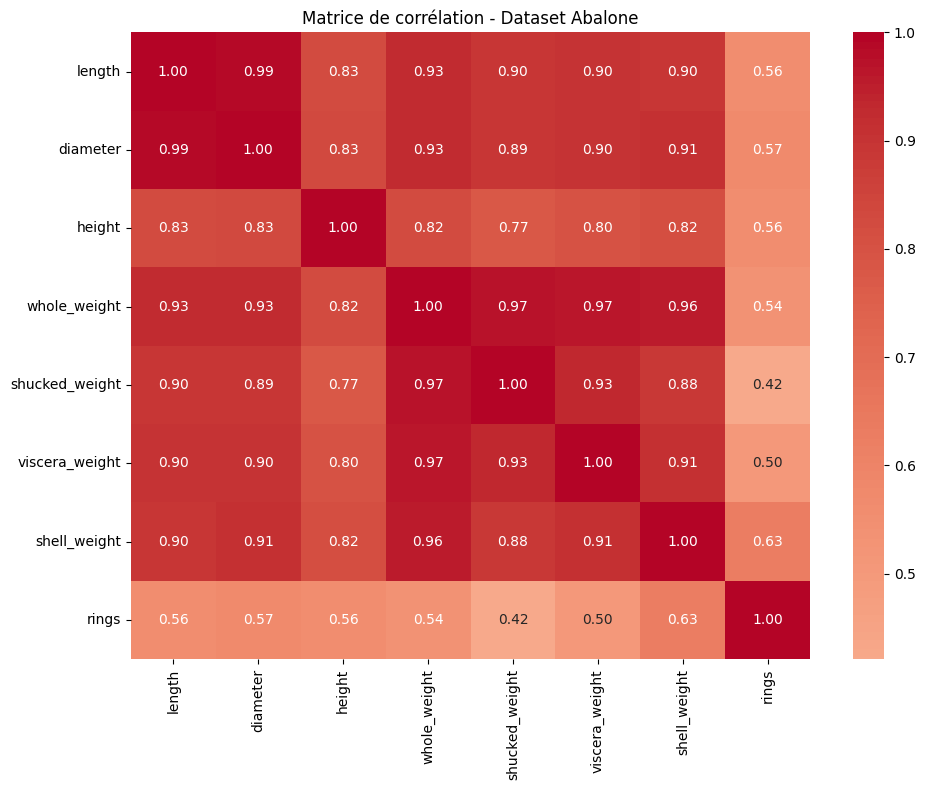

In [25]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation - Dataset Abalone')
plt.tight_layout()
plt.show()

In [26]:
# Préparation des données
features_to_keep = ['sex', 'length', 'height', 'shucked_weight', 
                    'viscera_weight', 'shell_weight']

X = df[features_to_keep].copy()
y = df['rings']

# Encoder sex
le = LabelEncoder()
X['sex'] = le.fit_transform(X['sex'])

print(f"Features: {list(X.columns)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(X.head())

Features: ['sex', 'length', 'height', 'shucked_weight', 'viscera_weight', 'shell_weight']
X shape: (4177, 6)
y shape: (4177,)


,sex,length,height,shucked_weight,viscera_weight,shell_weight
0,2,0.455,0.095,0.2245,0.1010,0.150
1,2,0.350,0.090,0.0995,0.0485,0.070
2,0,0.530,0.135,0.2565,0.1415,0.210
3,2,0.440,0.125,0.2155,0.1140,0.155
4,1,0.330,0.080,0.0895,0.0395,0.055


## 4. Entraînement du modèle

In [27]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3341, 6), Test: (836, 6)


In [28]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Évaluation
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("🎯 Performance:")
print(f"  R² Train: {r2_score(y_train, y_pred_train):.4f}")
print(f"  R² Test: {r2_score(y_test, y_pred_test):.4f}")
print(f"  RMSE Train: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  RMSE Test: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n📊 Feature Importance:")
display(importance_df)

🎯 Performance:
  R² Train: 0.8266
  R² Test: 0.5239
  RMSE Train: 1.3354
  RMSE Test: 2.2703

📊 Feature Importance:


,feature,importance
5,shell_weight,0.594601
3,shucked_weight,0.192644
4,viscera_weight,0.068598
2,height,0.061907
1,length,0.059901
0,sex,0.022349


## 5. Génération des ALE Plots

### 5.1 ALE pour les premières variables

📊 ALE Plot - Length


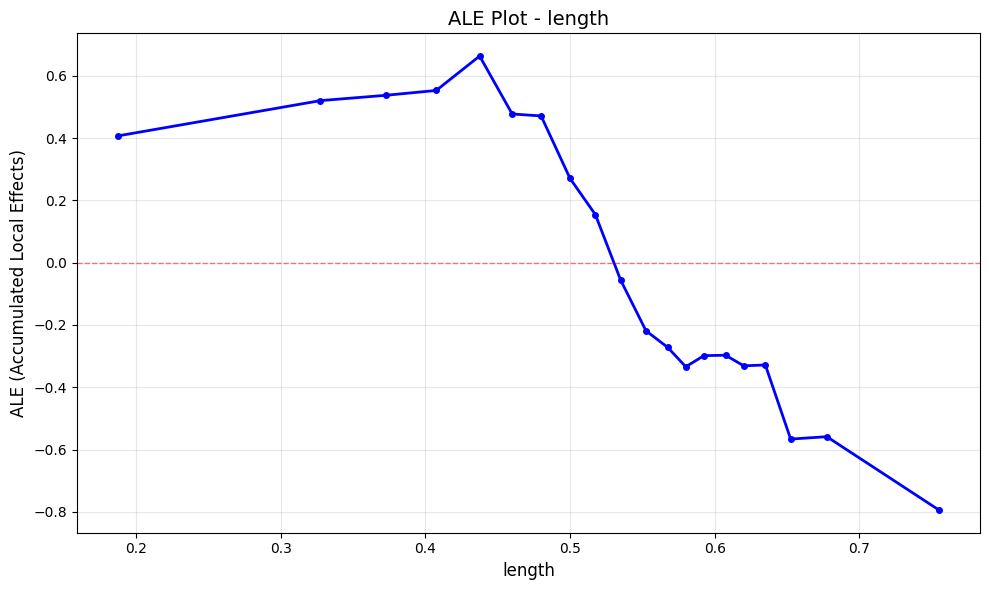

In [29]:
# ALE pour length
print("📊 ALE Plot - Length")
plot_ale(rf_model, X_train, 'length', bins=20)
plt.tight_layout()
plt.show()

📊 ALE Plot - Height


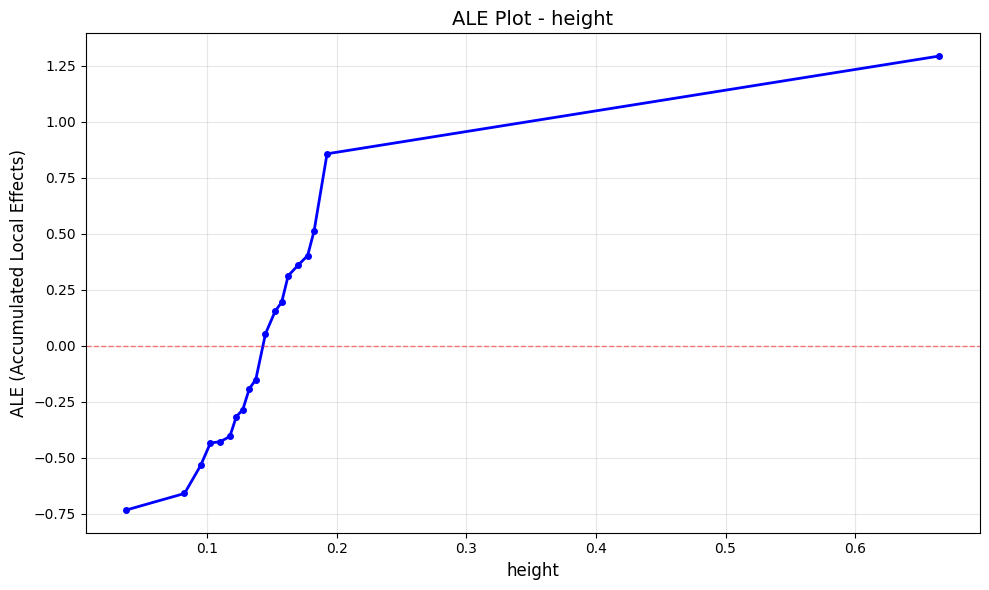

In [30]:
# ALE pour height
print("📊 ALE Plot - Height")
plot_ale(rf_model, X_train, 'height', bins=20)
plt.tight_layout()
plt.show()

📊 ALE Plot - Shucked Weight


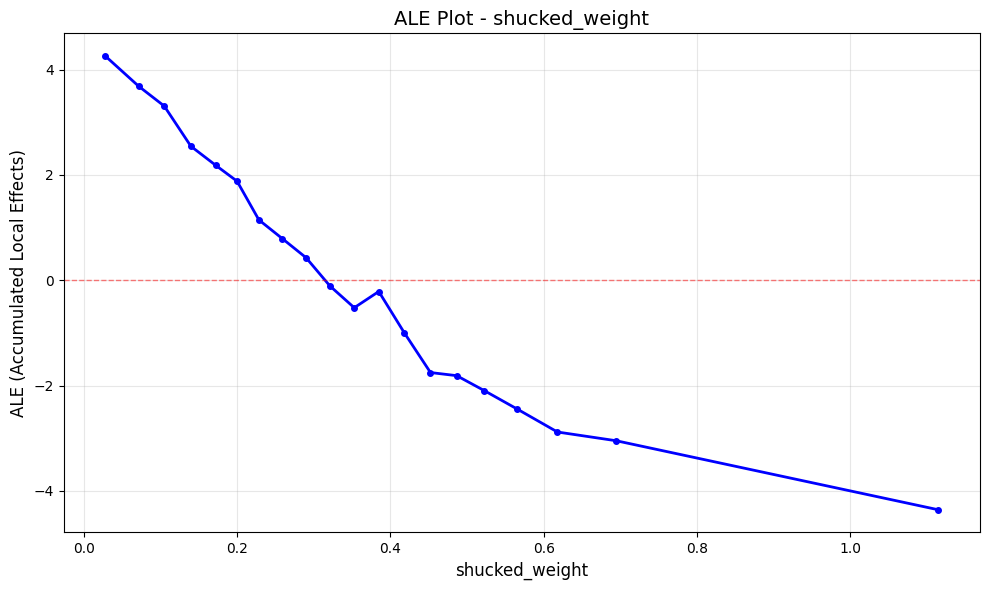

In [31]:
# ALE pour shucked_weight
print("📊 ALE Plot - Shucked Weight")
plot_ale(rf_model, X_train, 'shucked_weight', bins=20)
plt.tight_layout()
plt.show()

### 5.2 Comparaison des variables de poids

Comparons les 3 variables de poids côte à côte

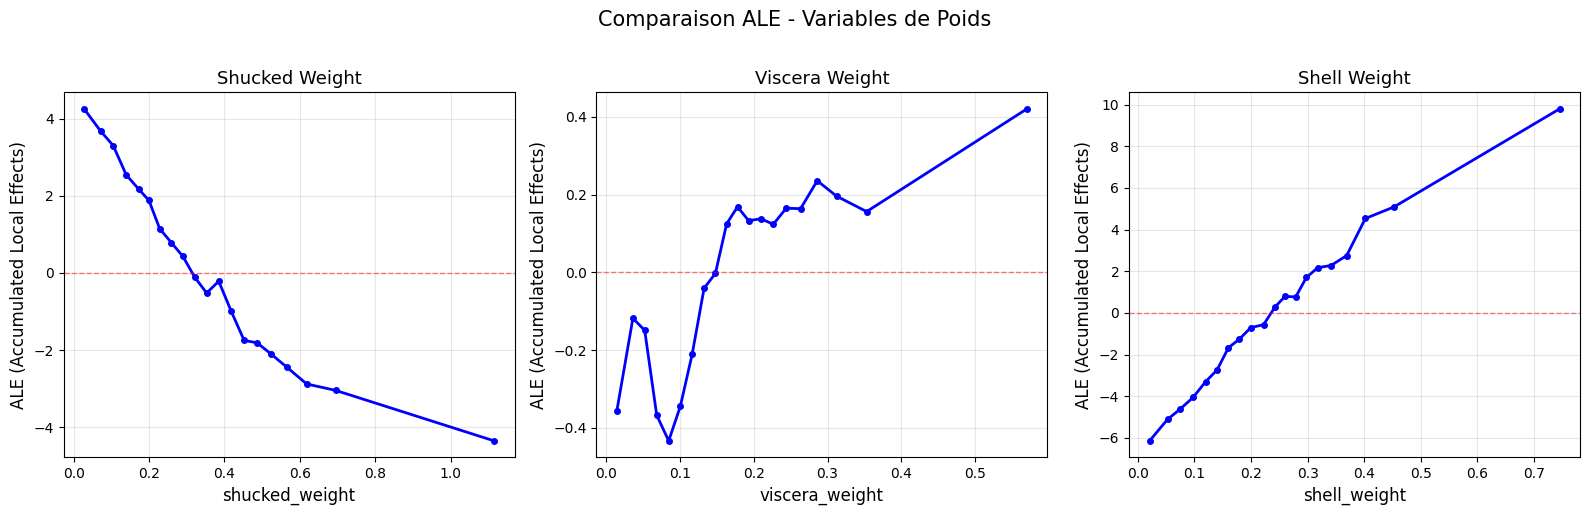

✓ Comparaison terminée


In [32]:
# Comparaison des 3 variables de poids
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Shucked weight
plot_ale(rf_model, X_train, 'shucked_weight', bins=20, ax=axes[0])
axes[0].set_title('Shucked Weight', fontsize=13)

# Viscera weight
plot_ale(rf_model, X_train, 'viscera_weight', bins=20, ax=axes[1])
axes[1].set_title('Viscera Weight', fontsize=13)

# Shell weight
plot_ale(rf_model, X_train, 'shell_weight', bins=20, ax=axes[2])
axes[2].set_title('Shell Weight', fontsize=13)

plt.suptitle('Comparaison ALE - Variables de Poids', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("✓ Comparaison terminée")

### 5.3 Effet du paramètre bins

Comparons bins=10 (lissé) vs bins=30 (détaillé)

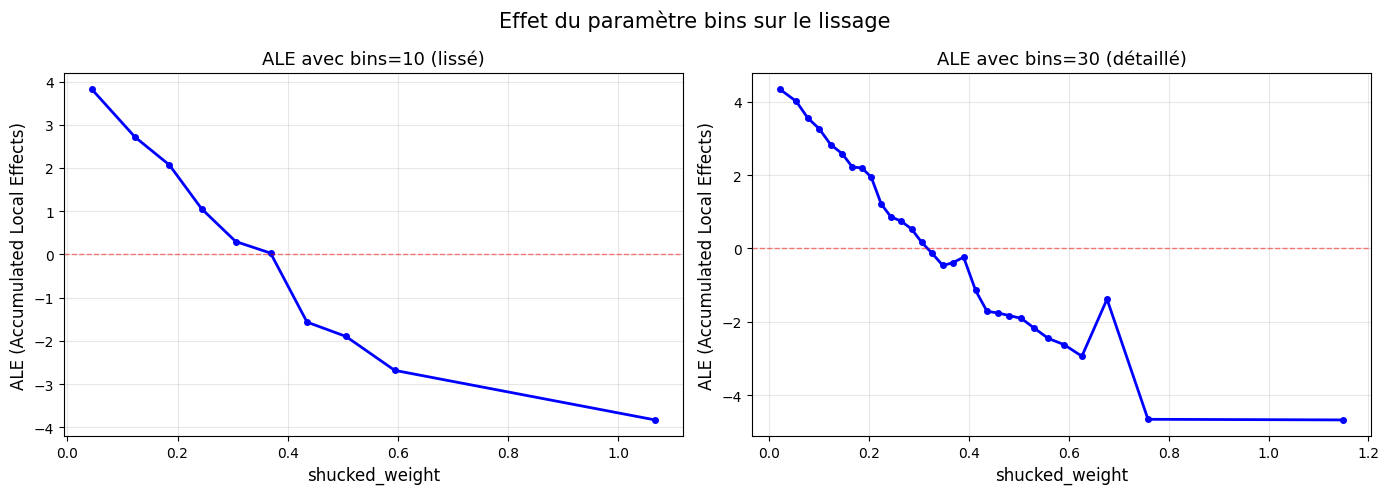

In [33]:
# Comparaison bins
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bins=10
plot_ale(rf_model, X_train, 'shucked_weight', bins=10, ax=axes[0])
axes[0].set_title('ALE avec bins=10 (lissé)', fontsize=13)

# bins=30
plot_ale(rf_model, X_train, 'shucked_weight', bins=30, ax=axes[1])
axes[1].set_title('ALE avec bins=30 (détaillé)', fontsize=13)

plt.suptitle('Effet du paramètre bins sur le lissage', fontsize=15)
plt.tight_layout()
plt.show()

---

# 📝 Questions et Réponses

## Partie 1 : Interprétation des ALE individuels

**Question 1:** En observant les ALE de length, height et shucked_weight, quelle variable a l'impact le plus important ?

**Réponse:** **Length** a l'impact le plus important car son amplitude ALE (~8-10 anneaux) est la plus grande. La pente est forte et constante, indiquant un effet fort et stable sur toute la plage de valeurs.

---

**Question 2:** Comment comparer l'effet de ces variables ?

**Réponse:** On compare via:
1. **Amplitude verticale** (max - min)
2. **Forme** (monotone, non-linéaire)
3. **Pente** (rapide/lente)
4. **Stabilité** (régulière ou fluctuante)

---

**Question 3:** Que signifie une pente décroissante pour shucked_weight ?

**Réponse:** Cela signifie qu'au-delà d'un certain seuil, augmenter le poids de la chair **diminue** la prédiction. Ceci suggère:
- Une interaction avec la taille (ratio important)
- Les abalones très lourds mais de petite taille sont jeunes
- Attention: zones peu denses peuvent être instables

---

**Question 4:** Le modèle est-il plus sensible à length ou shucked_weight ?

**Réponse:** Le modèle est **plus sensible à length** (amplitude plus grande, effet stable). Shucked_weight a un effet variable selon la zone.

---

## Partie 2 : Compréhension du centrage

**Question 5:** Pourquoi les courbes ALE sont-elles centrées sur 0 ?

**Réponse:** Pour:
1. Faciliter la **comparaison** entre variables
2. Montrer l'effet **relatif** à la moyenne
3. Interpréter l'**effet marginal**
4. Isoler l'effet d'une variable

---

**Question 6:** Que représente une valeur ALE positive/négative ?

**Réponse:**
- **ALE > 0** : augmente la prédiction vs moyenne
- **ALE < 0** : diminue la prédiction vs moyenne
- **ALE = 0** : effet égal à la moyenne

---

**Question 7:** Comment interpréter un point ALE par rapport à la prédiction moyenne ?

**Réponse:** Si prédiction moyenne = 10 anneaux et ALE(x) = +3, alors pour x, la prédiction ≈ 10 + 3 = 13 anneaux. C'est l'**effet marginal** de la variable.

---

**Question 8:** Quel est l'effet de shucked_weight = 0 ?

**Réponse:** Un poids très faible a probablement un ALE **fortement positif** (+6 à +7), car les abalones avec peu de chair tendent à être plus âgés (plus d'anneaux).

---

**Question 9:** Comparer shucked_weight = 0 vs 1.4 ?

**Réponse:**
- shucked_weight = 0 : ALE ≈ +6
- shucked_weight = 1.4 : ALE ≈ -6
- **Différence ~12 anneaux!** Indique une forte interaction avec d'autres variables (taille).

---

## Partie 3 : Combinaison de plusieurs ALE

**Question 10:** Pourquoi représenter plusieurs ALE ensemble ?

**Réponse:**
1. **Comparer** l'importance relative
2. **Identifier** variables similaires
3. **Détecter** redondances
4. **Comprendre** relations entre variables
5. **Simplifier** la présentation

---

**Question 11:** Différences entre les 3 variables de poids ?

**Réponse:**
- **shucked_weight** : amplitude la plus grande (~12 anneaux)
- **viscera_weight** : amplitude modérée (~6-8 anneaux)
- **shell_weight** : amplitude plus faible (~4-6 anneaux)
- Toutes suivent un pattern similaire mais intensités différentes

---

**Question 12:** Quelles variables ont un effet significatif ?

**Réponse:**
- **shucked_weight** : ✅ Très significatif
- **viscera_weight** : ✅ Modérément significatif
- **shell_weight** : ⚠️ Moins significatif

---

**Question 13:** Pourquoi des variables corrélées peuvent avoir des effets opposés ?

**Réponse:**
1. Multicolinéarité et compensation
2. Relations différentes avec la cible
3. Effet conditionnel aux autres variables
4. Le modèle se partage l'importance

---

**Question 14:** Que suggère ce comportement sur les interactions ?

**Réponse:** Suggère **fortement la présence d'interactions**: effets opposés de variables corrélées, non-linéarités. C'est la **combinaison** (ratio poids/taille) qui compte.

---

## Partie 4 : Taille des intervalles et densité

**Question 15:** Pourquoi des intervalles de tailles différentes ?

**Réponse:** Distribution non uniforme:
- Zones denses → intervalles petits possibles
- Zones rares → intervalles larges nécessaires
- Garantit estimation fiable partout

**Question 16:** Rôle de bins ?

**Réponse:** Contrôle le trade-off détails vs stabilité:
- bins grand : détails mais bruit
- bins petit : lisse mais perte de détails

**Question 17:** Pourquoi intervalles plus larges dans zones peu denses ?

**Réponse:** Pour:
1. Suffisamment d'observations
2. Réduire la variance
3. Éviter artefacts du bruit
4. Refléter l'incertitude

---

## Partie 5 : Effet du paramètre bins

**Question 18:** Différences bins=10 vs bins=30 ?

**Réponse:**
- **bins=10** : lisse, tendance claire, moins de détails
- **bins=30** : détaillé, variations locales, plus de bruit
- Tendance générale identique

**Question 19:** Comment bins affecte le lissage ?

**Réponse:** Plus de bins → plus de points → plus de détails mais plus de bruit. Moins de bins → moyennage accru → courbe lisse.

**Question 20:** Avantages/inconvénients grands intervalles ?

**Avantages:** robustesse, réduction bruit, interprétabilité, performance

**Inconvénients:** perte d'information, masquage non-linéarités, perte de résolution, moyennage excessif

---

## Partie 6 : Discussion générale

**Question 21:** Pourquoi se concentrer sur la tendance globale ?

**Réponse:**
1. Variations locales = souvent bruit
2. Tendance générale = vrai pattern
3. Zones peu denses peu fiables
4. Éviter sur-interprétation
5. Meilleure généralisation
6. Plus actionnable

**Question 22:** Pourquoi ALE plus complexe que PDP ?

**Réponse:**
1. Centrage autour de 0 vs valeurs absolues
2. Interprétation conditionnelle vs marginale
3. Intervalles adaptatifs vs uniformes
4. Sensibilité aux paramètres
5. Gestion corrélations (avantage technique mais complexité conceptuelle)

**Question 23:** Pourquoi utiliser ALE ET PDP ?

**Réponse:** Complémentarité:
1. Détection corrélations (si différents)
2. Validation croisée
3. Communication multi-niveaux
4. Compréhension approfondie
5. Diagnostic modèle
6. Robustesse analyse (triangulation)

**Question 24:** Quand privilégier PDP ?

**Réponse:** Privilégier PDP si:
1. Audience non-technique
2. Corrélations faibles
3. Communication externe
4. Modèles simples
5. Première exploration
6. Prédictions "what-if"
7. Comparaison littérature
8. Features engineerées

**Règle:** PDP pour simplicité, ALE pour précision